In [2]:
# 패키지 불러오기

# Native libraries
import os
import math

# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 전처리
from sklearn.preprocessing import MinMaxScaler

# 알고리즘
from minisom import MiniSom
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.clustering import TimeSeriesKMeans
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [3]:
# 데이터 불러오기

df = pd.read_csv("sample_2019_3y_cafe.csv", encoding = 'cp949')
df = df[~df['day_after1'].isin([0])]

# id별 시리즈 생성
grouped = df.groupby('public_id')
series_dict = {pid: group.set_index('day_after1')['sales_ratio'] for pid, group in grouped}
mySeries = {key: series.sort_index() for key, series in series_dict.items()}
namesofMyseries = []
for key in mySeries.keys():
    namesofMyseries.append(key)

In [4]:
print(namesofMyseries)

[58032, 58363, 65510, 68651, 139348, 184493, 271017, 316179, 353070, 373020, 445278, 498228, 575044, 580893, 670318, 747898, 829515, 1055028, 1108814, 1112495, 1136847, 1157388, 1251942, 1333363, 1344865, 1440499, 1441444, 1442410, 1461321, 1608207, 1759752, 1938480, 2140864, 2253074, 2278341, 2300949, 2682313, 2711431, 2809786, 2824196, 2884374, 2979768, 2995640, 3008083, 3035753, 3163074, 3179775, 3181242, 3243091, 3261412, 3283745, 3310356, 3346347, 3403382, 3590185, 3704370, 3809489, 3827449, 3872035, 3900904, 3920867, 3975714, 4024226, 4115147, 4130866, 4188281, 4301729, 4368906, 4396608, 4418255, 4431915, 4432258, 4518401, 4555078, 4581075, 4625891, 4636963, 4675171, 4682262, 4698656, 4733282, 4746897, 4827176, 4902266, 4914679, 4946667, 4973419, 5004390, 5102379, 5153034, 5153368, 5204225, 5210530, 5236302, 5254825, 5272076, 5342565, 5363786, 5401984, 5412133, 5432585, 5516264, 5545150, 5612676, 5630644, 5640565, 5660651, 5773259, 5786791, 5814964, 5985141, 6042590, 6046022, 605

In [5]:
print(len(mySeries))

1975


In [6]:
mySeries1 = list(mySeries.values())
mySeries1

[day_after1
 1      0.000037
 2      0.000039
 3      0.000033
 4      0.000038
 5      0.000032
          ...   
 158    0.000010
 159    0.000010
 160    0.000009
 161    0.000012
 162    0.000011
 Name: sales_ratio, Length: 161, dtype: float64,
 day_after1
 1      0.000319
 2      0.000308
 3      0.000294
 4      0.000273
 5      0.000245
          ...   
 158    0.000034
 159    0.000032
 160    0.000037
 161    0.000031
 162    0.000033
 Name: sales_ratio, Length: 161, dtype: float64,
 day_after1
 1      0.000068
 2      0.000073
 3      0.000070
 4      0.000065
 5      0.000063
          ...   
 158    0.000006
 159    0.000005
 160    0.000005
 161    0.000005
 162    0.000005
 Name: sales_ratio, Length: 162, dtype: float64,
 day_after1
 35     0.000017
 36     0.000021
 37     0.000027
 38     0.000016
 39     0.000015
          ...   
 158    0.000004
 159    0.000004
 160    0.000008
 161    0.000005
 162    0.000005
 Name: sales_ratio, Length: 126, dtype: float64,
 day_aft

In [7]:
# id별 시간 날짜 개수 산출

series_lengths = {len(series) for series in mySeries1}
print(series_lengths)

{128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 94, 100, 103, 105, 107, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 122, 124, 125, 126, 127}


In [8]:
# 최소 날짜 개수 설정

mySeries1 = [sublist for sublist in mySeries1 if len(sublist) >= 95]

In [9]:
max_len = max(series_lengths)
longest_series = None
for series in mySeries1:
    if len(series) == max_len:
        longest_series = series

In [10]:
problems_index = []

for i in range(len(mySeries1)):
    if len(mySeries1[i])!= max_len:
        problems_index.append(i)
        mySeries1[i] = mySeries1[i].reindex(longest_series.index)

In [11]:
def nan_counter(list_of_series):
    nan_polluted_series_counter = 0
    for series in list_of_series:
        if series.isnull().sum().sum() > 0:
            nan_polluted_series_counter+=1
    print(nan_polluted_series_counter)

In [12]:
nan_counter(mySeries1)

1470


In [13]:
# 날짜 채우기로 인한 NA값 가장 가까운 매출값으로 채우기

for i in problems_index:
    mySeries1[i].interpolate(limit_direction="both",inplace=True)

In [14]:
nan_counter(mySeries1)

0


In [15]:
# 매출 데이터에 MinMax 스케일 적용

for i in range(len(mySeries1)):
    scaler = MinMaxScaler()
    # 데이터를 2차원 배열로 변환
    data_reshaped = np.array(mySeries1[i]).reshape(-1, 1)
    mySeries1[i] = scaler.fit_transform(data_reshaped)
    # 다시 1차원 배열로 변환
    mySeries1[i] = mySeries1[i].reshape(-1)

In [16]:
print("max: "+str(max(mySeries1[0]))+"\tmin: "+str(min(mySeries1[0])))
print(mySeries1[0][:5])

max: 1.0	min: 0.0
[0.95451706 1.         0.81413833 0.96534737 0.77771729]


In [17]:
# K-means 클러스터링

km = TimeSeriesKMeans(n_clusters=9, metric="dtw")

labels = km.fit_predict(mySeries1)

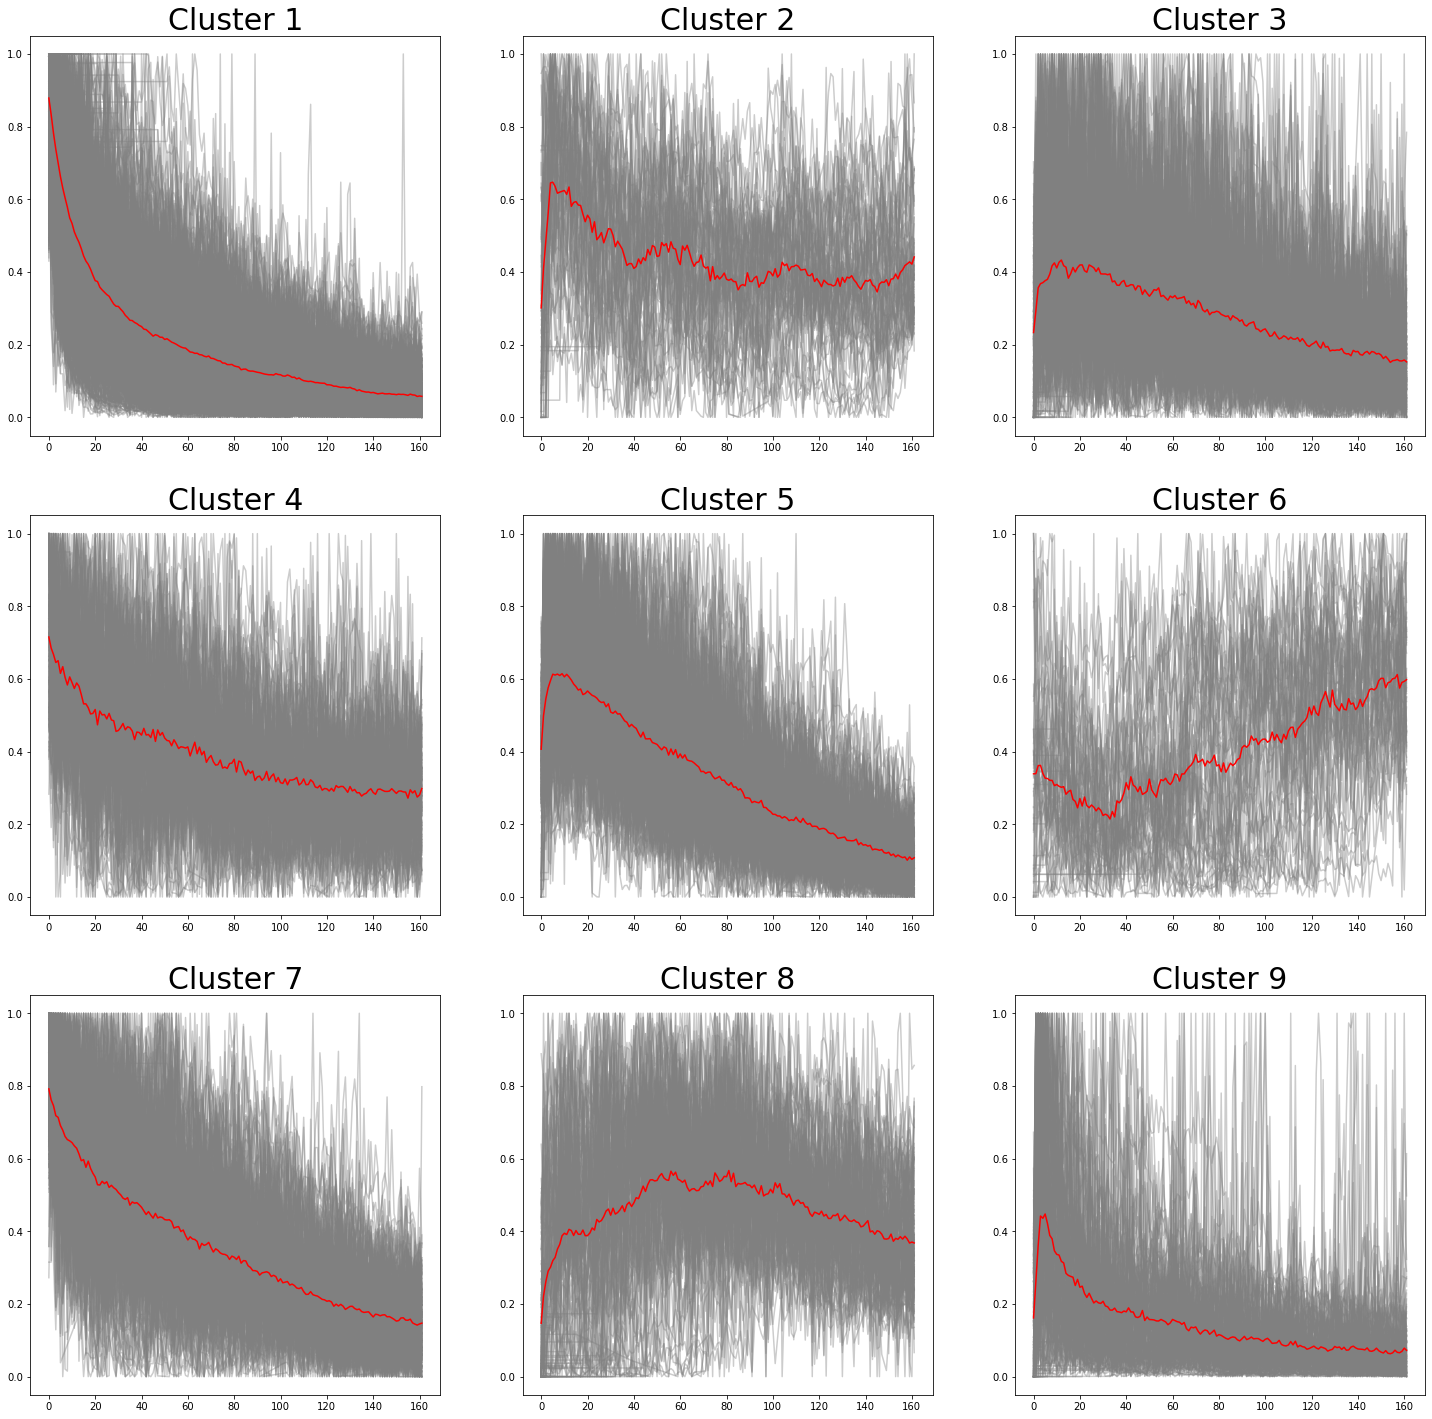

In [681]:
# 그래프 확인

plot_count = 9

fig, axs = plt.subplots(3, 3, figsize=(25,25))

rows = 3 
columns = 3

row_i=0
column_j=0

for label in set(labels):
    cluster = []
    for i in range(len(labels)):
        if labels[i] == label:
            axs[row_i, column_j].plot(mySeries1[i], c="gray", alpha=0.4)
            cluster.append(mySeries1[i])
    if len(cluster) > 0:
        axs[row_i, column_j].plot(np.average(np.vstack(cluster), axis=0), c="red")
    axs[row_i, column_j].set_title("Cluster " + str(label+1), fontsize = 30)

    # Update column and row indices
    column_j += 1
    if column_j >= columns:
        row_i += 1
        column_j = 0 
        
plt.show()

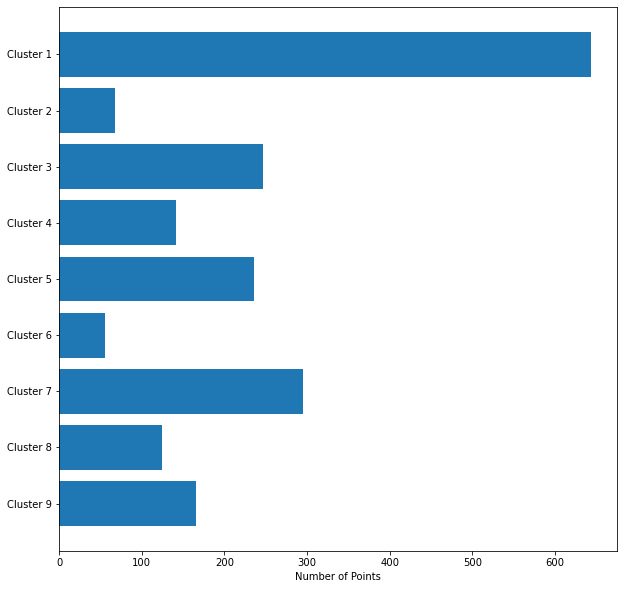

In [682]:
# 클러스터별 분포 확인

cluster_c = [len(labels[labels==i]) for i in range(9)]
cluster_n = ["Cluster "+str(i+1) for i in range(9)]

cluster_c = cluster_c[::-1]
cluster_n = cluster_n[::-1]

# Creating a horizontal bar graph with x and y axes swapped
plt.figure(figsize=(10, 10))
plt.barh(cluster_n, cluster_c)  # Using barh for horizontal bars
plt.xlabel("Number of Points")
plt.show()

In [683]:
# 클러스터링 통계치 확인

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


# Inertia
inertia = km.inertia_

# Silhouette Score
silhouette = silhouette_score(mySeries1, labels)

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(mySeries1, labels)

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(mySeries1, labels)

print("Inertia:", inertia)
print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski_harabasz)
print("Davies-Bouldin Index:", davies_bouldin)

Inertia: 0.7990110266523841
Silhouette Score: 0.03230659130194273
Calinski-Harabasz Index: 144.21239063884138
Davies-Bouldin Index: 3.925340373507685


In [684]:
# 분류된 클러스터 라벨 결합

# fancy_names_for_labels = [f"Cluster {label}" for label in labels]
# res = pd.DataFrame(zip(namesofMyseries,fancy_names_for_labels),columns=["Series","Cluster"]).sort_values(by="Cluster").set_index("Series")
# res
# res.to_csv("D:/credit/training/label/kmeans_2019_3y_cafe.csv")